# Supervised, Unsupervised and Reinforcement Learning

This notebook shows the three learning approaches on small, simple examples.
Libraries needed: `pandas`, `numpy`, `scikit-learn`, `matplotlib`

If you're missing any of them, run this once:
```
pip install pandas numpy scikit-learn matplotlib
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans

---
## 1. Supervised Learning: Classification

**Idea:** we give the model examples **with the correct answer (label)**. It learns the pattern and predicts the label for new data.

**Real-world use:** reading handwritten postcodes on letters, cheque amounts at banks, spam detection, fraud detection.

**Dataset:** the handwritten digits dataset, built into scikit-learn. It has 1,797 small images of handwritten numbers 0 to 9.
- **Features (inputs):** each image is 8 x 8 pixels = **64 numbers**. Each number is how dark that pixel is (0 = white, 16 = black).
- **Label (answer):** which digit it is (0 to 9).

### Step 1: Look at the dataset

Number of images: 1797
Size of each image: (8, 8)


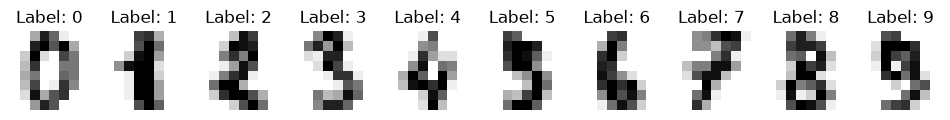

In [2]:
digits = load_digits()

print("Number of images:", len(digits.images))
print("Size of each image:", digits.images[0].shape)

# Show the first 10 images with their labels
fig, axes = plt.subplots(1, 10, figsize=(12, 2))
for ax, image, label in zip(axes, digits.images, digits.target):
    ax.imshow(image, cmap="gray_r")
    ax.set_title(f"Label: {label}")
    ax.axis("off")
plt.show()

In [3]:
# What the computer actually sees: the first image (a 0) as an 8 x 8 grid of numbers
pd.DataFrame(digits.images[1]).astype(int)

,0,1,2,3,4,5,6,7
0,0,0,0,12,13,5,0,0
1,0,0,0,11,16,9,0,0
2,0,0,3,15,16,6,0,0
3,0,7,15,16,16,2,0,0
4,0,0,1,16,16,3,0,0
5,0,0,1,16,16,6,0,0
6,0,0,1,16,16,6,0,0
7,0,0,0,11,16,10,0,0


In [4]:
# As a table: each image is flattened into one row of 64 pixel values, plus its label
df = pd.DataFrame(digits.data, columns=[f"pixel_{i}" for i in range(64)]).astype(int)
df["label"] = digits.target
print("Rows, columns:", df.shape)
df.head()

Rows, columns: (1797, 65)


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,label
0,0,0,5,13,9,1,0,0,0,0,...,0,0,0,6,13,10,0,0,0,0
1,0,0,0,12,13,5,0,0,0,0,...,0,0,0,0,11,16,10,0,0,1
2,0,0,0,4,15,12,0,0,0,0,...,0,0,0,0,3,11,16,9,0,2
3,0,0,7,15,13,1,0,0,0,8,...,0,0,0,7,13,13,9,0,0,3
4,0,0,0,1,11,0,0,0,0,0,...,0,0,0,0,2,16,4,0,0,4


In [5]:
# How many examples of each digit? (the labels)
df["label"].value_counts().sort_index()

label
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64

### Step 2: Train the model
We split the data: **80% for training** (the model sees these images and their answers) and **20% for testing** (kept hidden, used to check the model).

The model is **k-Nearest Neighbors**: to read a new image, it finds the 3 most similar training images and takes their most common label.

In [6]:
X = digits.data      # features: 64 pixel values per image
y = digits.target    # labels: the digit 0-9

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training images:", len(X_train), "| Test images:", len(X_test))

# model = DecisionTreeClassifier()
model = KNeighborsClassifier()

model.fit(X_train, y_train)   # <-- training happens here
print("Model trained!")

Training images: 1437 | Test images: 360
Model trained!


### Step 3: Test and predict

In [7]:
# How good is it on images it has never seen?
y_pred = model.predict(X_test)
print("Accuracy on test data:", round(accuracy_score(y_test, y_pred) * 100, 1), "%")

# Side by side: actual answer vs the model's prediction
pd.DataFrame({"actual": y_test, "predicted": y_pred}).head(10)

Accuracy on test data: 98.6 %


,actual,predicted
0,6,6
1,9,9
2,3,3
3,7,7
4,2,2
5,1,1
6,5,5
7,2,2
8,5,5
9,2,2


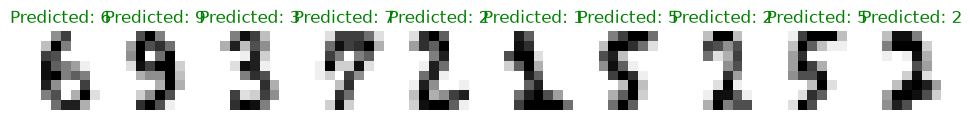

In [8]:
# Look at some test images with the model's predictions (green = correct, red = wrong)
fig, axes = plt.subplots(1, 10, figsize=(12, 2))
for ax, image, actual, pred in zip(axes, X_test, y_test, y_pred):
    ax.imshow(image.reshape(8, 8), cmap="gray_r")
    ax.set_title(f"Predicted: {pred}", color="green" if pred == actual else "red")
    ax.axis("off")
plt.show()

Wrong predictions: 5 out of 360


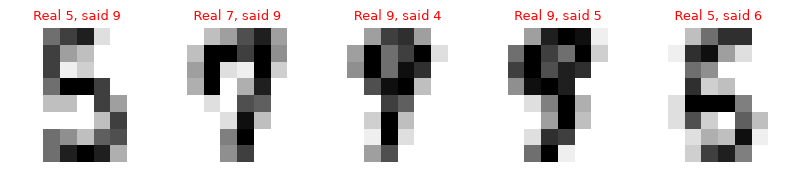

In [9]:
# Any mistakes? Show the ones it got wrong
wrong = np.where(y_pred != y_test)[0]
print("Wrong predictions:", len(wrong), "out of", len(y_test))
fig, axes = plt.subplots(1, min(len(wrong), 8), figsize=(10, 2), squeeze=False)
for ax, i in zip(axes[0], wrong[:8]):
    ax.imshow(X_test[i].reshape(8, 8), cmap="gray_r")
    ax.set_title(f"Real {y_test[i]}, said {y_pred[i]}", color="red", fontsize=9)
    ax.axis("off")
plt.show()

---
## 2. Unsupervised Learning: Clustering

**Idea:** the data has **no labels**. The model finds groups of similar items on its own.

**Real-world use:** customer segmentation, grouping similar articles, detecting unusual activity.

**Dataset:** 200 shop customers with two columns: annual income and a spending score (1 to 100). Nobody has told us which "type" each customer is.

### Step 1: Look at the dataset

In [10]:
rng = np.random.default_rng(0)
centers = [(25, 20), (25, 80), (55, 50), (90, 20), (90, 80)]   # hidden groups (the model never sees these)
rows = []
for cx, cy in centers:
    for _ in range(40):
        rows.append([round(rng.normal(cx, 7)), round(rng.normal(cy, 7))])
customers = pd.DataFrame(rows, columns=["annual_income_k", "spending_score"]).clip(lower=1)
customers = customers.sample(frac=1, random_state=0).reset_index(drop=True)

print("Rows, columns:", customers.shape)
customers.head(10)   # note: no label column!

Rows, columns: (200, 2)


,annual_income_k,spending_score
0,20,19
1,83,82
2,54,54
3,46,46
4,100,80
5,84,73
6,21,20
7,94,25
8,31,21
9,92,20


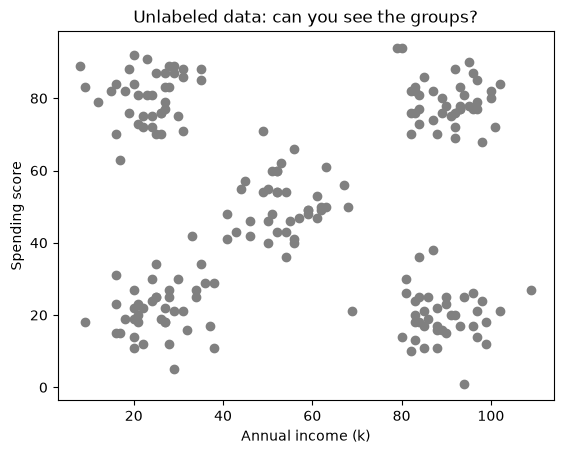

In [11]:
plt.scatter(customers["annual_income_k"], customers["spending_score"], color="gray")
plt.xlabel("Annual income (k)"); plt.ylabel("Spending score")
plt.title("Unlabeled data: can you see the groups?")
plt.show()

## Step 2: Train the model (K-Means)
K-Means is told **how many groups** to find (k = 5). It then:
1. places 5 centre points,
2. assigns each customer to the nearest centre,
3. moves each centre to the middle of its customers,
4. repeats until nothing changes.

In [12]:
kmeans = KMeans(n_clusters=5, n_init=10, random_state=0)
customers["group"] = kmeans.fit_predict(customers[["annual_income_k", "spending_score"]])   # training

customers.head(10)   # the model added a group number to every customer

\\?\C:\Users\nilotpal.chandra\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,annual_income_k,spending_score,group
0,20,19,3
1,83,82,4
2,54,54,1
3,46,46,1
4,100,80,4
5,84,73,4
6,21,20,3
7,94,25,2
8,31,21,3
9,92,20,2


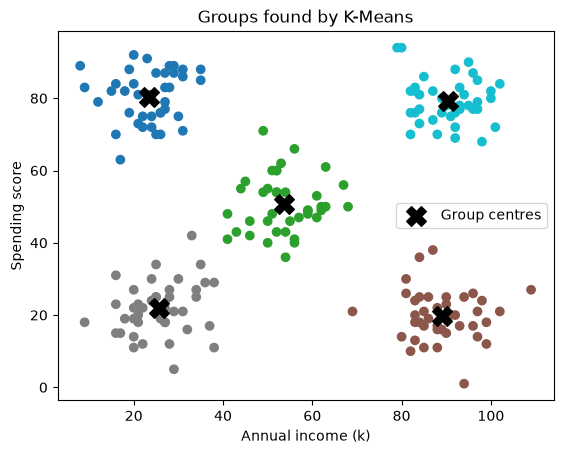

In [13]:
plt.scatter(customers["annual_income_k"], customers["spending_score"], c=customers["group"], cmap="tab10")
c = kmeans.cluster_centers_
plt.scatter(c[:, 0], c[:, 1], color="black", marker="X", s=200, label="Group centres")
plt.xlabel("Annual income (k)"); plt.ylabel("Spending score")
plt.title("Groups found by K-Means"); plt.legend(); plt.show()

### Step 3: Understand the groups and predict
The model only gives group **numbers**. A person looks at each group's averages and gives it a meaning.

In [14]:
summary = customers.groupby("group")[["annual_income_k", "spending_score"]].mean().round(1)
summary["customers"] = customers["group"].value_counts().sort_index()
summary
# e.g. high income + high spending = "premium shoppers", low income + low spending = "budget shoppers"

,annual_income_k,spending_score,customers
group,,,
0,23.4,80.5,40
1,53.7,50.6,39
2,89.0,19.8,40
3,25.6,21.8,41
4,90.5,79.2,40


In [15]:
# Which group does a new customer belong to?
new_customer = pd.DataFrame([[88, 85]], columns=["annual_income_k", "spending_score"])
print("New customer:", new_customer.values[0], "-> group", kmeans.predict(new_customer)[0])

New customer: [88 85] -> group 4


---
## 3. Reinforcement Learning: Q-Learning

**Idea:** there is no dataset at the start. An **agent** takes **actions** in an **environment**, receives **rewards** (good) or **penalties** (bad), and learns by trial and error which action is best in each **state**. That learned strategy is its **policy**.

**Real-world use:** game-playing AI, robots, traffic lights, recommendation systems.

**Environment:** a robot in a small 4x4 warehouse.
- `S` = start, `G` = goal (**+10 reward**), `X` = hole (**-10 penalty**), `.` = floor
- Every move costs **-1**, so the robot learns to take the shortest safe path.

### Step 1: Look at the environment

In [16]:
grid = [
    ["S", ".", ".", "."],
    [".", "X", ".", "X"],
    [".", ".", ".", "X"],
    ["X", ".", ".", "G"],
]
print("\n".join(" ".join(row) for row in grid))

ACTIONS = ["up", "down", "left", "right"]
MOVES = {"up": (-1, 0), "down": (1, 0), "left": (0, -1), "right": (0, 1)}

def step(state, action):
    """The environment: returns (next_state, reward, done)."""
    r, c = state
    dr, dc = MOVES[action]
    nr, nc = min(max(r + dr, 0), 3), min(max(c + dc, 0), 3)   # walls keep the robot inside
    cell = grid[nr][nc]
    if cell == "G": return (nr, nc), 10, True
    if cell == "X": return (nr, nc), -10, True
    return (nr, nc), -1, False

S . . .
. X . X
. . . X
X . . G


### Step 2: Train the agent
The **Q-table** stores how good each action is in each cell. It starts at all zeros (the robot knows nothing).

After every move the robot updates it:

`Q[state, action] = Q + learning_rate x (reward + discount x best future Q - Q)`

It also **explores** (random moves) at the start and **exploits** (best known move) more as it learns.

In [17]:
Q = np.zeros((4, 4, len(ACTIONS)))
learning_rate, discount, epsilon = 0.1, 0.9, 1.0
random = np.random.default_rng(42)
rewards_per_episode = []

for episode in range(500):
    state, done, total = (0, 0), False, 0
    while not done:
        if random.random() < epsilon:                         # explore
            a = random.integers(len(ACTIONS))
        else:                                                 # exploit
            a = np.argmax(Q[state])
        next_state, reward, done = step(state, ACTIONS[a])
        best_future = 0 if done else np.max(Q[next_state])
        Q[state][a] += learning_rate * (reward + discount * best_future - Q[state][a])   # learning
        state, total = next_state, total + reward
    epsilon = max(0.05, epsilon * 0.99)                        # explore less over time
    rewards_per_episode.append(total)

print("Training finished: 500 episodes")

Training finished: 500 episodes


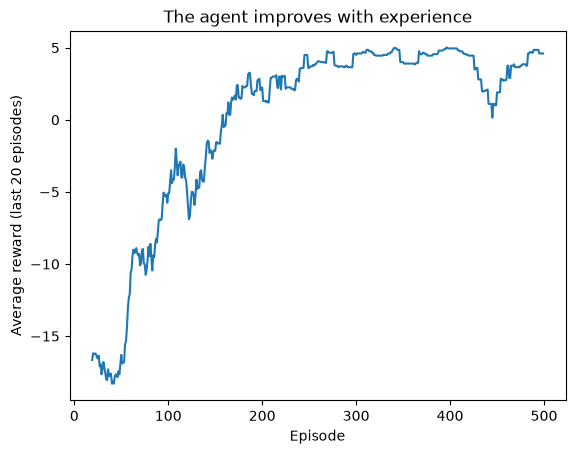

In [18]:
# Total reward per episode goes up as the robot learns
plt.plot(pd.Series(rewards_per_episode).rolling(20).mean())
plt.xlabel("Episode"); plt.ylabel("Average reward (last 20 episodes)")
plt.title("The agent improves with experience"); plt.show()

In [19]:
# The learned Q-table for the start cell: higher = better action
pd.DataFrame(Q[0, 0].reshape(1, -1), columns=ACTIONS, index=["start cell (0,0)"]).round(2)

,up,down,left,right
"start cell (0,0)",-0.79,1.81,-0.72,-2.14


### Step 3: Use the learned policy
The policy is simply: **in each cell, take the action with the highest Q-value.**

In [20]:
arrows = {"up": "↑", "down": "↓", "left": "←", "right": "→"}
policy = [[grid[r][c] if grid[r][c] in "XG" else arrows[ACTIONS[np.argmax(Q[r, c])]]
           for c in range(4)] for r in range(4)]
print("Learned policy (best move in each cell):")
print("\n".join(" ".join(row) for row in policy))

state, path, done = (0, 0), [(0, 0)], False
while not done and len(path) < 20:
    state, reward, done = step(state, ACTIONS[np.argmax(Q[state])])
    path.append(state)
print("\nRobot's path from start:", path)
print("Reached the goal!" if grid[state[0]][state[1]] == "G" else "Did not reach the goal")

Learned policy (best move in each cell):
↓ → ↓ ←
↓ X ↓ X
→ → ↓ X
X → → G

Robot's path from start: [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (3, 2), (3, 3)]
Reached the goal!


---
## Summary

| | Supervised | Unsupervised | Reinforcement |
|---|---|---|---|
| **Data** | Labeled (features + answer) | Unlabeled (features only) | No dataset; learns by interacting |
| **Learns from** | Correct answers | Patterns/similarity in the data | Rewards and penalties |
| **Output** | A category or a number | Groups / structure | A policy (best action per state) |
| **Example here** | Handwritten digits, house prices | Customer groups | Robot finding the goal |
| **Algorithms** | Decision tree, linear regression, logistic regression, random forest | K-Means, DBSCAN, PCA | Q-Learning, DQN, PPO |
| **Real world** | Spam filters, fraud detection, price prediction | Customer segmentation, topic grouping, anomaly detection | Games, robotics, traffic control |